# Let's get going and preprocess some data 😏
 إنسان الي كاتب والله 😂

## Starter Code (Provided by the supervisor)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, models, callbacks
from keras.datasets import cifar10
from keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val   = x_train_full[40000:].astype('float32')
y_val   = y_train_full[40000:]
x_test  = x_test.astype('float32')

print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 121s 1us/step
Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


## Helping Functions (also proivded by the supervisor) ربنا يخليهولنا

In [2]:
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te,
                       epochs=20, batch_size=128, extra_callbacks=None):
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()
    history = model.fit(x_tr, to_categorical(y_tr, 10),
                        validation_data=(x_v, to_categorical(y_v, 10)),
                        epochs=epochs, batch_size=batch_size,
                        callbacks=cb, verbose=0)
    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time: {elapsed:.1f}s")
    return history, test_acc, test_loss, elapsed

def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

## The actual data preprocessing (Finally 🥱)
I'm the one who wrote the code, but since I didn't know a lot about tensorflow, I asked GPT-5 mini about how to write it first. (and then Gemini Pro 3.1 because mini 5 decided just decided suddenly to blank out)

In [3]:
def build_baseline_cnn(input_shape = (32, 32, 3), num_classes = 10):
    """
    builds a 4-layer CNN model using ReLU as an activatiation function

    Arguments:
        input_shape -- shape of the data "length, width, color channels (RGB)" (tuple)
        num_classes -- number of classes (int)

    Returns:
        Fully constructed CNN model ()
    """

    m = models.Sequential([
        layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same', input_shape = input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation = 'relu', padding = 'same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation = 'relu'),
        layers.Dense(num_classes, activation = 'softmax'),
    ])

    m.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
    return m

## Preprocessing helper functions

In [4]:
def preprocess_none(x):
    return x.astype('float32')

def preprocess_minmax(x):
    return x.astype('float32') / 255.0

def compute_train_stats(x_train):
    x = x_train.astype('float32')
    mean = x.mean(axis = (0,1,2))
    std = x.std(axis = (0,1,2))
    return mean, std

def preprocess_standardize(x, mean, std):
    return (x.astype('float32') - mean) / std

## Let's try and check if everything runs well or not 🙃

In [5]:
# Let's start by building the model
model = build_baseline_cnn()

# Then let's create the different variations of data with different types of preprocessing for the different expirments.
x_train_exp_a = preprocess_none(x_train) # Features as they are with nothing changed
x_train_exp_b = preprocess_minmax(x_train) # Normalized features.
train_mean, train_std = compute_train_stats(x_train) # X_train mean and standard deviation.
x_train_exp_c = preprocess_standardize(x_train, train_mean, train_std) # X_train standardized per channel.
x_val_exp_a = preprocess_none(x_val)
x_val_exp_b = preprocess_minmax(x_val)
x_val_exp_c = preprocess_standardize(x_val, train_mean, train_std)
x_test_exp_a = preprocess_none(x_test)
x_test_exp_b = preprocess_minmax(x_test)
x_test_exp_c = preprocess_standardize(x_test, train_mean, train_std)

# Time to try and train the actual model that we've built
history_exp_a, test_acc_exp_a, test_loss_exp_a, elapsed_exp_a = train_and_evaluate(model, x_train_exp_a, y_train, x_val_exp_a, y_val, x_test_exp_a, y_test)
history_exp_b, test_acc_exp_b, test_loss_exp_b, elapsed_exp_b = train_and_evaluate(model, x_train_exp_b, y_train, x_val_exp_b, y_val, x_test_exp_b, y_test)
history_exp_c, test_acc_exp_c, test_loss_exp_c, elapsed_exp_c = train_and_evaluate(model, x_train_exp_c, y_train, x_val_exp_c, y_val, x_test_exp_c, y_test)

c:\Users\ayman\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.5276 | Test Loss: 3.0893 | Time: 415.3s
Test Acc: 0.6570 | Test Loss: 1.4618 | Time: 394.1s
Test Acc: 0.6601 | Test Loss: 3.1525 | Time: 375.7s


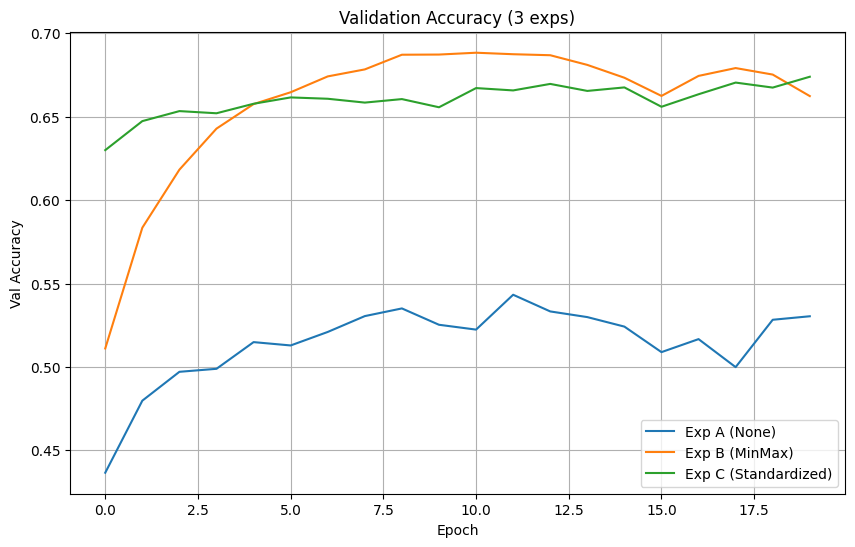

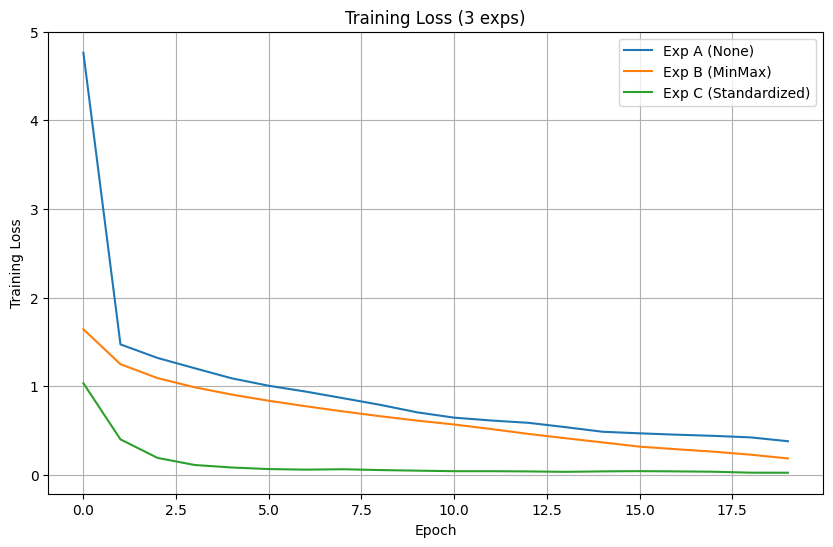

In [6]:
# Now let's gather the histories together to plot them out.
histories = [history_exp_a, history_exp_b, history_exp_c]
labels = ['Exp A (None)','Exp B (MinMax)','Exp C (Standardized)']

# Finally the plotting step 🤩
plot_curves(histories, labels, metric = 'val_accuracy', title = "Validation Accuracy (3 exps)", ylabel = "Val Accuracy")
plot_curves(histories, labels, metric = 'loss', title = "Training Loss (3 exps)", ylabel = "Training Loss")


In [7]:
# Experiment A: None (0-255)
train_acc_a = history_exp_a.history['accuracy'][-1]
val_acc_a = history_exp_a.history['val_accuracy'][-1]
test_acc_a = test_acc_exp_a
loss1_a = history_exp_a.history['loss'][0]

# Experiment B: Min-Max [0,1]
train_acc_b = history_exp_b.history['accuracy'][-1]
val_acc_b = history_exp_b.history['val_accuracy'][-1]
test_acc_b = test_acc_exp_b
loss1_b = history_exp_b.history['loss'][0]

# Experiment C: Standardized
train_acc_c = history_exp_c.history['accuracy'][-1]
val_acc_c = history_exp_c.history['val_accuracy'][-1]
test_acc_c = test_acc_exp_c
loss1_c = history_exp_c.history['loss'][0]

# Print as a table
print(f"{'Preprocessing':<15} {'Train Acc':<10} {'Val Acc':<10} {'Test Acc':<10} {'Loss @ Epoch 1':<15}")
print(f"{'None (0-255)':<15} {train_acc_a:.4f}    {val_acc_a:.4f}    {test_acc_a:.4f}    {loss1_a:.4f}")
print(f"{'Min-Max [0,1]':<15} {train_acc_b:.4f}    {val_acc_b:.4f}    {test_acc_b:.4f}    {loss1_b:.4f}")
print(f"{'Standardized':<15} {train_acc_c:.4f}    {val_acc_c:.4f}    {test_acc_c:.4f}    {loss1_c:.4f}")

Preprocessing   Train Acc  Val Acc    Test Acc   Loss @ Epoch 1 
None (0-255)    0.8696    0.5304    0.5276    4.7638
Min-Max [0,1]   0.9416    0.6624    0.6570    1.6427
Standardized    0.9924    0.6740    0.6601    1.0333


***

### Now, time to try something different, data augmentation 🧩

but first, let's see how training goes without it.

In [8]:
model_no_aug = build_baseline_cnn()
history_no_aug, _, _, _ = train_and_evaluate(model_no_aug,
                                             x_train_exp_c, y_train,
                                             x_val_exp_c, y_val,
                                             x_test_exp_c, y_test,
                                             epochs = 40, batch_size = 128)

Test Acc: 0.6784 | Test Loss: 3.1961 | Time: 684.6s


### Let's now augment some data 😊

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range = 15,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True,
    zoom_range = 0.1
)

datagen.fit(x_train_exp_c)
model_aug = build_baseline_cnn()

history_aug = model_aug.fit(
    datagen.flow(x_train_exp_c, to_categorical(y_train, 10), batch_size = 128),
    validation_data = (x_val_exp_c, to_categorical(y_val, 10)),
    epochs = 40,
    steps_per_epoch = len(x_train_exp_c) // 128,
    verbose = 1 
)

Epoch 1/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 45s 132ms/step - accuracy: 0.4592 - loss: 1.5166 - val_accuracy: 0.5404 - val_loss: 1.3042
Epoch 2/40
  1/312 ━━━━━━━━━━━━━━━━━━━━ 20s 67ms/step - accuracy: 0.5625 - loss: 1.2208

c:\Users\ayman\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5625 - loss: 1.2208 - val_accuracy: 0.5538 - val_loss: 1.2654
Epoch 3/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 47s 150ms/step - accuracy: 0.5724 - loss: 1.2072 - val_accuracy: 0.6116 - val_loss: 1.1339
Epoch 4/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5391 - loss: 1.2501 - val_accuracy: 0.6081 - val_loss: 1.1452
Epoch 5/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 49s 157ms/step - accuracy: 0.6147 - loss: 1.0942 - val_accuracy: 0.6530 - val_loss: 1.0164
Epoch 6/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6484 - loss: 1.0546 - val_accuracy: 0.6554 - val_loss: 1.0060
Epoch 7/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 46s 147ms/step - accuracy: 0.6399 - loss: 1.0253 - val_accuracy: 0.6655 - val_loss: 0.9845
Epoch 8/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6484 - loss: 0.9870 - val_accuracy: 0.6677 - val_loss: 0.9732
Epoch 9/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 45s 144ms/step - accuracy: 0.6583 - loss: 0.9714 - val_accuracy: 

### let's use AI to save some time in the plotting 😅, this next bit of code was AI written but HI understood (Human Intelligence) 😂

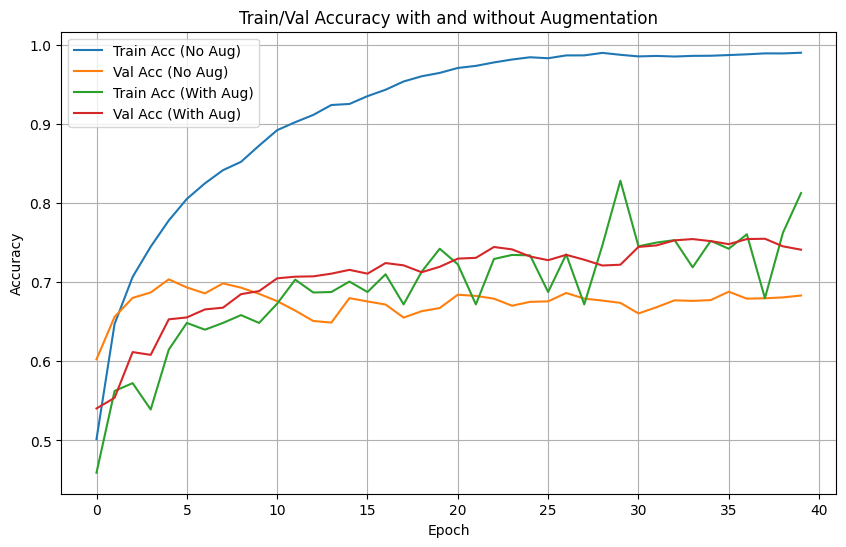

In [10]:
# Collect histories and labels
histories = [history_no_aug, history_aug]
labels = ['Train Acc (No Aug)', 'Train Acc (With Aug)']

# Plot training accuracy
plt.figure(figsize=(10, 6))
plt.plot(history_no_aug.history['accuracy'], label='Train Acc (No Aug)')
plt.plot(history_no_aug.history['val_accuracy'], label='Val Acc (No Aug)')
plt.plot(history_aug.history['accuracy'], label='Train Acc (With Aug)')
plt.plot(history_aug.history['val_accuracy'], label='Val Acc (With Aug)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train/Val Accuracy with and without Augmentation')
plt.legend()
plt.grid(True)
plt.show()

### Nearly forgot the gap thingy 🫠

In [11]:
# Get last epoch's accuracy
train_acc_no_aug = history_no_aug.history['accuracy'][-1]
val_acc_no_aug = history_no_aug.history['val_accuracy'][-1]
train_acc_aug = history_aug.history['accuracy'][-1]
val_acc_aug = history_aug.history['val_accuracy'][-1]

print(f"No Augmentation: Train-Val Gap = {train_acc_no_aug - val_acc_no_aug:.4f}")
print(f"With Augmentation: Train-Val Gap = {train_acc_aug - val_acc_aug:.4f}")

if abs(train_acc_aug - val_acc_aug) < abs(train_acc_no_aug - val_acc_no_aug):
    print("Data augmentation overfits less.")
else:
    print("No augmentation overfits less.")

No Augmentation: Train-Val Gap = 0.3067
With Augmentation: Train-Val Gap = 0.0715
Data augmentation overfits less.


# Everything for the very first part of our expirments is done 🤩
تم بحمد الله وفضله 🩵

***

# Second Expirment is on its way, chooo chooooo 🚂

### First things first, we need a moduler function that takes the **number of filters** as a *parameter*. So, why don't we take the old function, tune it a bit, and Wala 🪄, a moduler function 🤩
and to learn from our previous mistakes, input shape is depricated, we can use an input layer instead to map things correctly.

In [12]:
from keras.layers import Input
def moduler_build_baseline_cnn(input_shape = (32, 32, 3), num_classes = 10, l1_f_count = 8, l2_f_count = 8, l3_f_count = 16, l4_f_count = 16):
    """
    builds a moduler 6-layer CNN model using ReLU as an activatiation function

    Arguments:
        input_shape -- shape of the data "length, width, color channels (RGB)" (tuple)
        num_classes -- number of classes (int)

    Returns:
        Fully constructed CNN model ()
    """

    m = models.Sequential([
        layers.Input(input_shape),
        layers.Conv2D(l1_f_count, (3,3), activation = 'relu', padding = 'same'),
        layers.Conv2D(l2_f_count, (3,3), activation = 'relu', padding = 'same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(l3_f_count, (3,3), activation = 'relu', padding = 'same'),
        layers.Conv2D(l4_f_count, (3,3), activation = 'relu', padding = 'same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(256, activation = 'relu'),
        layers.Dense(num_classes, activation = 'softmax'),
    ])

    m.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
    return m

### Let's now try building this model with different filter counts, and see the difference, would this  affect the accuarcy ? and how does it scale with the number of learned parameters ?? Let's find out 🔎

In [13]:
l1_f_count, l2_f_count, l3_f_count, l4_f_count = 8, 8, 16, 16
small_model = moduler_build_baseline_cnn(l1_f_count = l1_f_count, l2_f_count = l2_f_count, l3_f_count = l3_f_count, l4_f_count = l4_f_count)
# Let's change the number of filters to build a bigger model.
l1_f_count, l2_f_count, l3_f_count, l4_f_count = 32, 32, 64, 64
not_that_small_model = moduler_build_baseline_cnn(l1_f_count = l1_f_count, l2_f_count = l2_f_count, l3_f_count = l3_f_count, l4_f_count = l4_f_count)
# Another change for even a bigger one.
l1_f_count, l2_f_count, l3_f_count, l4_f_count = 64, 64, 128, 128
large_model = moduler_build_baseline_cnn(l1_f_count = l1_f_count, l2_f_count = l2_f_count, l3_f_count = l3_f_count, l4_f_count = l4_f_count)
print("""\n
    #################################################################
      All models now are fully built, let's see how do they look 😉
    #################################################################\n""")
print("Let's start with the smallest.")
print(small_model.summary())
print("""\n
##############################
Then the not that small one.
##############################\n""")
print(not_that_small_model.summary())
print("""\n
##############################
And the biggest of them all.
##############################\n""")
print(large_model.summary())




    #################################################################
      All models now are fully built, let's see how do they look 😉
    #################################################################

Let's start with the smallest.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,266 (1.03 MB)

 Trainable params: 269,266 (1.03 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,360,138 (9.00 MB)

 Trainable params: 2,360,138 (9.00 MB)

 Non-trainable params: 0 (0.00 B)

None


### Shall we now **train** the models or what 😉

In [14]:
history_small_model, test_acc_small_model, test_loss_small_model, elapsed_small_model = train_and_evaluate(small_model, x_train_exp_c, y_train, x_val_exp_c, y_val, x_test_exp_c, y_test)
history_not_that_small_model, test_acc_not_that_small_model, test_loss_not_that_small_model, elapsed_not_that_small_model = train_and_evaluate(not_that_small_model, x_train_exp_c, y_train, x_val_exp_c, y_val, x_test_exp_c, y_test)
history_large_model, test_acc_large_model, test_loss_large_model, elapsed_large_model = train_and_evaluate(large_model, x_train_exp_c, y_train, x_val_exp_c, y_val, x_test_exp_c, y_test)

Test Acc: 0.6107 | Test Loss: 2.3218 | Time: 233.1s
Test Acc: 0.7244 | Test Loss: 2.0736 | Time: 1179.6s
Test Acc: 0.7399 | Test Loss: 1.9470 | Time: 3081.2s


In [15]:
# Small Model: Standardized
train_acc_small_model = history_small_model.history['accuracy'][-1]
val_acc_small_model = history_small_model.history['val_accuracy'][-1]
small_model_total_parms = small_model.count_params()
# Medium Model: Standardized
train_acc_not_that_small_model = history_not_that_small_model.history['accuracy'][-1]
val_acc_not_that_small_model = history_not_that_small_model.history['val_accuracy'][-1]
not_that_small_model_total_parms = not_that_small_model.count_params()


# Large Model: Standardized
train_acc_large_model = history_large_model.history['accuracy'][-1]
val_acc_large_model = history_large_model.history['val_accuracy'][-1]
large_model_total_parms = large_model.count_params()


# Print as a table
print(f"{'Model':<10} {'Total Params' :<15}{'Train Acc':<10} {'Val Acc':<10} {'Test Acc':<10} {'Time(s)':<15}")
print(f"{'Small':<10} {small_model_total_parms:<15}{train_acc_small_model:.4f}     {val_acc_small_model:.4f}     {test_acc_small_model:.4f}     {elapsed_small_model:.4f}")
print(f"{'Medium':<10} {not_that_small_model_total_parms:<15}{train_acc_not_that_small_model:.4f}     {val_acc_not_that_small_model:.4f}     {test_acc_not_that_small_model:.4f}     {elapsed_not_that_small_model:.4f}")
print(f"{'Large':<10} {large_model_total_parms:<15}{train_acc_large_model:.4f}     {val_acc_large_model:.4f}     {test_acc_large_model:.4f}     {elapsed_large_model:.4f}")

Model      Total Params   Train Acc  Val Acc    Test Acc   Time(s)        
Small      269266         0.9279     0.6231     0.6107     233.0588
Medium     1116970        0.9844     0.7276     0.7244     1179.6413
Large      2360138        0.9862     0.7496     0.7399     3081.1864


### Now let's plot them using the same functions that we used to plot the first graph in the first expirment 😎

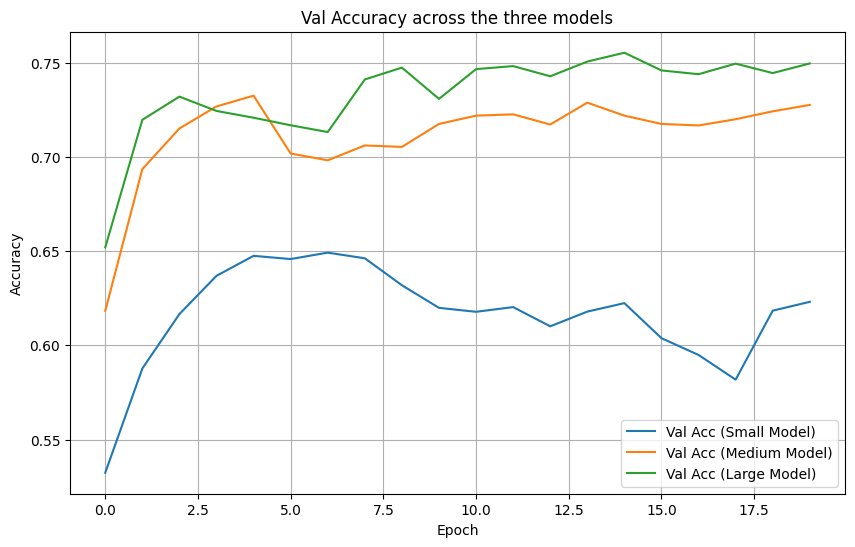

In [16]:
# Collect histories and labels
histories = [history_small_model, history_not_that_small_model, history_large_model]
labels = ['Val Acc (Small Model)', 'Val Acc (Medium Model)', 'Val Acc (Large Model)']

# Plot training accuracy
plt.figure(figsize=(10, 6))
plt.plot(histories[0].history['val_accuracy'], label = labels[0])
plt.plot(histories[1].history['val_accuracy'], label = labels[1])
plt.plot(histories[2].history['val_accuracy'], label = labels[2])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Val Accuracy across the three models')
plt.legend()
plt.grid(True)
plt.show()

### Time to expiriment with the depth instead of the number of filters 🌊

### Some planning for how to build the models 👷‍♂️

In [17]:
# First, let's start with a function that builds a shallow model.
def build_shallow_cnn(input_shape = (32, 32, 3), num_classes = 10):
    """
    builds a shallow 6-layer CNN model using ReLU as an activatiation function

    Arguments:
        input_shape -- shape of the data "length, width, color channels (RGB)" (tuple)
        num_classes -- number of classes (int)

    Returns:
        Fully constructed CNN model ()
    """

    m = models.Sequential([
        layers.Input(input_shape),
        layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same'),
        layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same'),
        layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(256, activation = 'relu'),
        layers.Dense(num_classes, activation = 'softmax'),
    ])

    m.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
    return m

# Then, let's implement a function that builds a medium-depth model.
from keras.layers import GlobalAveragePooling2D
def build_moderate_cnn(input_shape = (32, 32, 3), num_classes = 10):
    """
    builds a moderate 8-layer CNN model using ReLU as an activatiation function

    Arguments:
        input_shape -- shape of the data "length, width, color channels (RGB)" (tuple)
        num_classes -- number of classes (int)

    Returns:
        Fully constructed CNN model ()
    """

    m = models.Sequential([
        layers.Input(input_shape),
        layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same'),
        layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same'),
        layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same'),
        layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation = 'relu'),
        layers.Dense(num_classes, activation = 'softmax'),
    ])

    m.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
    return m

# Finally, its time for a deep model. 
def build_deep_cnn(input_shape = (32, 32, 3), num_classes = 10):
    """
    builds a deep 10-layer CNN model using ReLU as an activatiation function

    Arguments:
        input_shape -- shape of the data "length, width, color channels (RGB)" (tuple)
        num_classes -- number of classes (int)

    Returns:
        Fully constructed CNN model ()
    """

    m = models.Sequential([
        layers.Input(input_shape),
        layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same'),
        layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same'),
        layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same'),
        layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same'),
        layers.Conv2D(32, (3,3), activation = 'relu', padding = 'same'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation = 'relu'),
        layers.Dense(num_classes, activation = 'softmax'),
    ])

    m.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
    return m

### Since we now have the blueprints 🗺️, let's acutally build the models 🏗️

In [18]:
shallow_model = build_shallow_cnn()
moderate_model = build_moderate_cnn()
deep_model = build_deep_cnn()
print("""\n
    #################################################################
      All models now are fully built, let's see how do they look 😉
    #################################################################\n""")
print("Let's start with the smallest.")
print(shallow_model.summary())
print("""\n
##############################
Then the not that small one.
##############################\n""")
print(moderate_model.summary())
print("""\n
##############################
And the biggest of them all.
##############################\n""")
print(deep_model.summary())




    #################################################################
      All models now are fully built, let's see how do they look 😉
    #################################################################

Let's start with the smallest.


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 555,754 (2.12 MB)

 Trainable params: 555,754 (2.12 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,650 (299.41 KB)

 Trainable params: 76,650 (299.41 KB)

 Non-trainable params: 0 (0.00 B)

None


### Training Timeeeeee 👟

In [19]:
history_shallow_model, test_acc_shallow_model, test_loss_shallow_model, elapsed_shallow_model = train_and_evaluate(shallow_model, x_train_exp_c, y_train, x_val_exp_c, y_val, x_test_exp_c, y_test)
history_moderate_model, test_acc_moderate_model, test_loss_moderate_model, elapsed_moderate_model = train_and_evaluate(moderate_model, x_train_exp_c, y_train, x_val_exp_c, y_val, x_test_exp_c, y_test)
history_deep_model, test_acc_deep_model, test_loss_deep_model, elapsed_deep_model = train_and_evaluate(deep_model, x_train_exp_c, y_train, x_val_exp_c, y_val, x_test_exp_c, y_test)

Test Acc: 0.6913 | Test Loss: 2.4021 | Time: 634.7s
Test Acc: 0.7263 | Test Loss: 0.7934 | Time: 548.2s
Test Acc: 0.7169 | Test Loss: 0.9187 | Time: 548.4s


### I don't know if it is necessary that we see the numbers, but let's do it anyways 🙈

In [20]:
# Small Model: Standardized
train_acc_shallow_model = history_shallow_model.history['accuracy'][-1]
val_acc_shallow_model = history_shallow_model.history['val_accuracy'][-1]
shallow_model_total_parms = shallow_model.count_params()
# Medium Model: Standardized
train_acc_moderate_model = history_moderate_model.history['accuracy'][-1]
val_acc_moderate_model = history_moderate_model.history['val_accuracy'][-1]
moderate_model_total_parms = moderate_model.count_params()

# Large Model: Standardized
train_acc_deep_model = history_deep_model.history['accuracy'][-1]
val_acc_deep_model = history_deep_model.history['val_accuracy'][-1]
deep_model_total_parms = deep_model.count_params()


# Print as a table
print(f"{'Model':<10} {'Total Params' :<15}{'Train Acc':<10} {'Val Acc':<10} {'Test Acc':<10} {'Time(s)':<15}")
print(f"{'Shallow':<10} {shallow_model_total_parms:<15}{train_acc_shallow_model:.4f}     {val_acc_shallow_model:.4f}     {test_acc_shallow_model:.4f}     {elapsed_shallow_model:.4f}")
print(f"{'Moderate':<10} {moderate_model_total_parms:<15}{train_acc_moderate_model:.4f}     {val_acc_moderate_model:.4f}     {test_acc_moderate_model:.4f}     {elapsed_moderate_model:.4f}")
print(f"{'Deep':<10} {deep_model_total_parms:<15}{train_acc_deep_model:.4f}     {val_acc_deep_model:.4f}     {test_acc_deep_model:.4f}     {elapsed_deep_model:.4f}")

Model      Total Params   Train Acc  Val Acc    Test Acc   Time(s)        
Shallow    555754         0.9811     0.7035     0.6913     634.7486
Moderate   58154          0.7902     0.7366     0.7263     548.1531
Deep       76650          0.8235     0.7245     0.7169     548.4216


### Get ready for some plots once more 📊

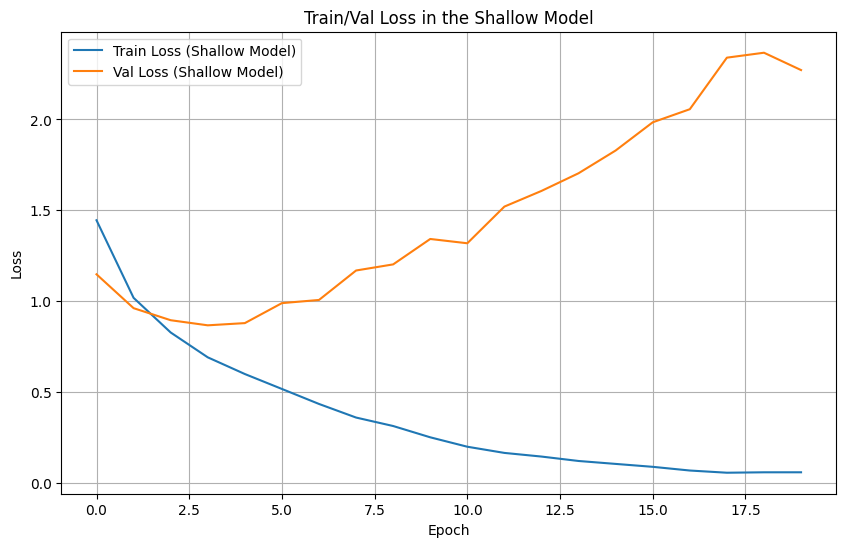

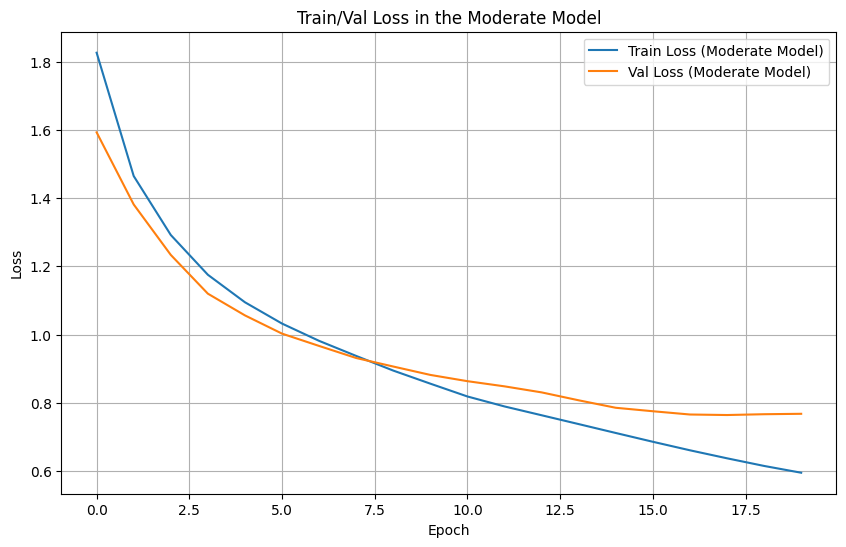

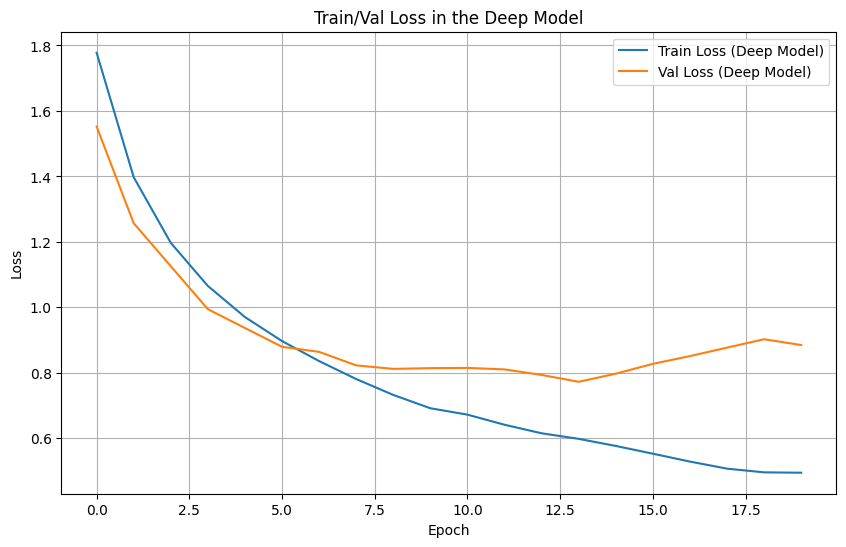

In [21]:
# Collect histories and labels
histories = [history_shallow_model, history_moderate_model, history_deep_model]
labels = ['Train Loss (Shallow Model)', 'Val Loss (Shallow Model)', 'Train Loss (Moderate Model)', 'Val Loss (Moderate Model)', 'Train Loss (Deep Model)', 'Val Loss (Deep Model)']

# Plot training accuracy
plt.figure(figsize=(10, 6))
plt.plot(histories[0].history['loss'], label = labels[0])
plt.plot(histories[0].history['val_loss'], label = labels[1])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train/Val Loss in the Shallow Model')
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(10, 6))
plt.plot(histories[1].history['loss'], label = labels[2])
plt.plot(histories[1].history['val_loss'], label = labels[3])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train/Val Loss in the Moderate Model')
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(10, 6))
plt.plot(histories[2].history['loss'], label = labels[4])
plt.plot(histories[2].history['val_loss'], label = labels[5])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train/Val Loss in the Deep Model')
plt.legend()
plt.grid(True)
plt.show()

### And this does answer a very important question: Does the deepest model perform best? Why or why not? 
The answer is simply **Nope**, the deepest model doesn't perform the best, it is the moderate one actually in our experiment.

And after some searching to answer the why question, in short:
<br>
<br>
1- If the data is simple, a **shallower** model may be able to catch all the important patterns, without the risk of **overfitting**, or the extra **computational** and **time** ***cost***.
<br>
<br>
2- Deeper models risk **vanishing/exploding gradinats** if used without some special techniques.

In [22]:
# ===== SAVE PREPROCESSED DATA FOR OTHER NOTEBOOKS =====
import os
import numpy as np

# Save standardized data and statistics for reuse in other notebooks
np.save('x_train_standardized.npy', x_train_exp_c)
np.save('x_val_standardized.npy', x_val_exp_c)
np.save('x_test_standardized.npy', x_test_exp_c)
np.save('train_mean.npy', train_mean)
np.save('train_std.npy', train_std)

print("Preprocessed data saved successfully!")
print("Files saved:")
print("  - x_train_standardized.npy")
print("  - x_val_standardized.npy")
print("  - x_test_standardized.npy")
print("  - train_mean.npy")
print("  - train_std.npy")

Preprocessed data saved successfully!
Files saved:
  - x_train_standardized.npy
  - x_val_standardized.npy
  - x_test_standardized.npy
  - train_mean.npy
  - train_std.npy
